In [1]:
import redback 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo 
import astropy.units as uu
from redback.transient_models.supernova_models import lambda_to_nu
import redback.interaction_processes as ip
import redback.sed as sed
import redback.photosphere as photosphere

import astropy.units as uu

import extinction
from extinction import ccm89, fitzpatrick99, apply, remove
from scipy.interpolate import RegularGridInterpolator
import sncosmo

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
13:28 bilby INFO    : Running bilby version: 2.3.0
13:28 redback INFO    : Running redback version: 1.12.1


In [2]:
from redback.model_library import all_models_dict

func = all_models_dict['sncosmo_models']

In [113]:
#try to just use time and frequency not as arrays and see what happens - code states they should be the same length !! 
#try earlier time:
#10.420000000074506,B,n/a,14.370000000000001,0.06

#try having frequency and time not as arrays 
AB_mag = 14.370000000000001 - 0.09 #B band correction 
#target_obs_times = np.array([10.420000000074506]) #days in observer frame 
#have to use two frequencies or two time points - pass in the same time point twice -- does this get the code working / does it bring up any errors ? 
target_obs_times = np.array([10.420000000074506, 10.420000000074506])
target_redshift = 0.0085
target_frequencies = 6.86300e+14 # B band 
wavelength = np.array([4371.07000]) #angstroms
target_milky_way_ebv = 0.059

baseline_flux = func(
    time=target_obs_times,
    redshift=target_redshift,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density', # Returns mJy
    frequency=target_frequencies,
    mw_extinction=True,           # Add MW dust for YOUR target
    ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
    # ADD THESE TWO LINES:
    model_kwarg_names=[], # This tells redback there are no extra SN parameters to loop through
    use_set_peak_magnitude = True,
    peak_abs_mag = -18.6,
    peak_time = 15  #changes ? 
)

print(baseline_flux)

[4.14881277 4.14881277] mJy


In [123]:
# 1. Generate the 1998bw 'baseline' at your target's redshift

#GRB event information: 
#check 98bw first to see if it returns with 1 

# AB_mag = 14.23 + 0.21 #Rc correction --> AB_mag -- WORKS ? 
# #target_obs_times = np.array([10.420000000074506]) #days in observer frame 
# #have to use two frequencies or two time points - pass in the same time point twice -- does this get the code working / does it bring up any errors ? 
# target_obs_times = np.array([10.420000000074506, 10.420000000074506])
# target_redshift = 0.0085
# target_frequencies = 4.61700e+14 # Pass as a float, not np.array([..])
# wavelength = np.array([6498.09000]) #angstroms
# target_milky_way_ebv = 0.059

#try a new datapoint from Jillian's 1998bw template 
#dt_days,filter,tel,mag,mag_err
#7.429999999850988,Rc,n/a,14.620000000000001,0.05

#datapoint beyond 10 days 
# 15.349999999776482,Rc,n/a,14.0,0.08

# AB_mag = 14.0 + 0.21 #Rc correction --> AB_mag -- WORKS -- 
# #have to use two frequencies or two time points - pass in the same time point twice -- does this get the code working / does it bring up any errors ? 
# target_obs_times = np.array([15.349999999776482, 15.349999999776482]) #worked for 10 days, does it work for 
# target_redshift = 0.0085
# target_frequencies = 4.61700e+14 # Rc
# wavelength = np.array([6498.09000]) #angstroms
# target_milky_way_ebv = 0.059

#bessell b so only use b band obs ?? 
#37.46000000011176,B,n/a,15.96,0.05
# AB_mag = 15.96 - 0.09 #B band correction 
# #target_obs_times = np.array([10.420000000074506]) #days in observer frame 
# #have to use two frequencies or two time points - pass in the same time point twice -- does this get the code working / does it bring up any errors ? 
# target_obs_times = np.array([37.46000000011176, 37.46000000011176])
# target_redshift = 0.0085
# target_frequencies = 	6.86300e+14 # B band 
# wavelength = np.array([4371.07000]) #angstroms
# target_milky_way_ebv = 0.059

#try earlier time:
#10.420000000074506,B,n/a,14.370000000000001,0.06 -- yeilds ratio of 2 - INCORRECT 
AB_mag = 14.370000000000001 - 0.09 #B band correction 
#target_obs_times = np.array([10.420000000074506]) #days in observer frame 
#have to use two frequencies or two time points - pass in the same time point twice -- does this get the code working / does it bring up any errors ? 
target_obs_times = np.array([10.420000000074506, 10.420000000074506])
target_redshift = 0.0085
target_frequencies = 	6.86300e+14 # B band 
wavelength = np.array([4371.07000]) #angstroms
target_milky_way_ebv = 0.059



baseline_flux = func(
    time=target_obs_times,
    redshift=target_redshift,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density', # Returns mJy
    frequency=target_frequencies,
    mw_extinction=True,           # Add MW dust for YOUR target
    ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
    # ADD THESE TWO LINES:
    model_kwarg_names=[], # This tells redback there are no extra SN parameters to loop through
    use_set_peak_magnitude = True,
    peak_abs_mag = -18.6,
    peak_time = 16  #changes ? 
)

print(baseline_flux)



[1.01830221 1.01830221] mJy


In [125]:
#amplitude works differently here - setting it to 1 is the wrong thing to do 
#suggested fix 
baseline_flux = func(
    time=target_obs_times,
    redshift=target_redshift,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density',
    frequency=target_frequencies,
    mw_extinction=True,
    ebv_mw=target_milky_way_ebv,
    model_kwarg_names=[], 
    use_set_peak_magnitude=True, 
    #dont define amplitude = 1 (this doesnt work for this code - instead use peak_abs_magnitude of 1998bw )
    peak_abs_mag=-18.6, # KEEP CONSTANT ?? dont forget -ve sign !! 19.1 Typical peak for SN 1998bw -- VERIFY THIS WITH JILLIANS DATA + OTHER PAPERS (try 23.68 - peak from Jillians data) -- no this just makes things higher :( 18.65 = BEST 
    peak_abs_mag_band='standard::b',
    magnitude_system='ab',
    peak_time = 16
    )
print(baseline_flux )


[1.01830221 1.01830221] mJy


In [126]:
#2. Calculate de-reddened flux density for GRB event 
#in this case it is 980425 but still need to calculate 

#to get a_v from E(B-V) 
a_v = target_milky_way_ebv * 3.1 

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print(f"This is the flux density of  GRB event without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event) 
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")

This is the flux density of  GRB event without extinction correction: 1.62930 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 2.03422 mJy


In [127]:
# 3. Take the ratio
flux_ratio = dereddened_flux_event / baseline_flux

print(flux_ratio)

#should be 1.0 !! 
# not equal to 1 when i run different datapoint from jillian file 
#try for another jillian datapoint - the original one at 10.42 days -- ratio still = 1 ?? = 1.5 so not really - can i plot jillians lightcurve and compare 

#no this doesnt work - STILL GETTING FACTOR OF 2 TOO BIG 

[1.99766207 1.99766207]


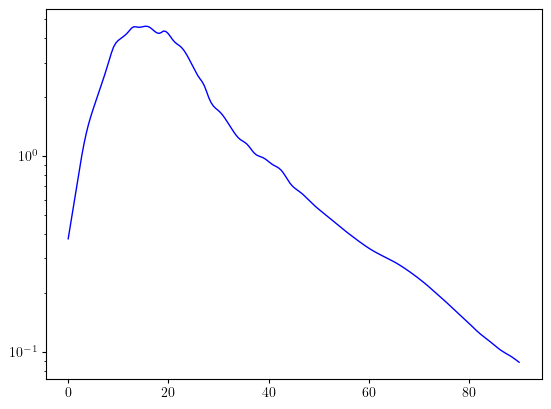

In [101]:
#plot this to see what is actually going on:
freq = target_frequencies
redshift = target_redshift
times = np.linspace(0.01,90,200)
sn_1998bw = func(time=times,
    redshift=redshift,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density', # Returns mJy
    frequency=target_frequencies,
    mw_extinction=True,           # Add MW dust for YOUR target
    ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
    model_kwarg_names=[], 
    use_set_peak_magnitude = True,
    peak_abs_mag = -18.6,
    peak_time = 16 #shifts pak time to where it actually is 
)

#now this is the correct lightcurve - DOES ANYTHING LOOK BETTER ? -- should change the flux density -- lowers a bit but still too much (still on the order of 1 though )
#change the peak from 20 to 17 and see if this changes anything ? -- yes - try 16 

#sn_1998bw1 = func(time=times,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density')

plt.semilogy(times,sn_1998bw,'-b')
#plt.semilogy(times,sn_1998bw1, '-r')
#this point is the arbitrary GRB event at the epoch 
#plt.semilogy(time,sn_1998b1, marker='o',color='green')
#plt.ylim(19,13)
plt.show()

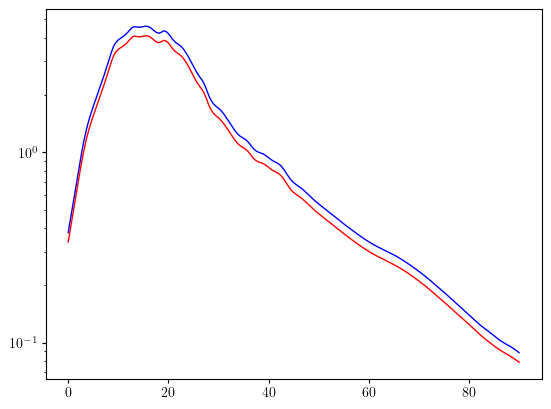

In [93]:
#add in another lightcurve to see if this changes 

freq = target_frequencies
redshift = target_redshift
times = np.linspace(0.01,90,200)
time = target_obs_times

sn_1998bw = func(time=times,
    redshift=redshift,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density', # Returns mJy
    frequency=target_frequencies,
    mw_extinction=True,           # Add MW dust for YOUR target
    ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
    model_kwarg_names=[], 
    use_set_peak_magnitude = True,
    peak_abs_mag = -18.6,
    peak_time = 16 #shifts pak time to where it actually is 
)

#now use this as the SN1998bw lightcueve and the above as the GRB event with redshift defined 
sn_1998bw1= func(time=times,
    redshift=0.009,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density', # Returns mJy
    frequency=target_frequencies,
    mw_extinction=True,           # Add MW dust for YOUR target
    ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
    model_kwarg_names=[], 
    use_set_peak_magnitude = True,
    peak_abs_mag = -18.6,
    peak_time = 16 #shifts pak time to where it actually is 
)


plt.semilogy(times,sn_1998bw,'-b')
plt.semilogy(times,sn_1998bw1, '-r')
#this point is the arbitrary GRB event at the epoch 
#plt.semilogy(time,sn_1998bw1, marker='o',color='green')
#plt.ylim(19,13)
plt.show()



In [ ]:
#current code for sncosmo model:
#problems include having to have two times the exact same, having to use amplitude != 1 ? having to input a peak_mag value (ok if i can get this to work for Jillian's data)
#not currently working for Jillians data but by using corect peak magnitude can work \? 

In [ ]:
#TO DO NEXT: use same values for AB_mag and peak mag to see if ratio = 1 ? )
#peak abs magnitude = ABSOLUTE MAGNITUDE M  not apparent magnitude m so have to do a conversion 

#found a correct valye for abs magnitude online 
#CHECK FOR DIFFERENT TIMES - DIFFERENT JILLIAN DATAPOINTS -- STILL WORKS ? 
#does this mean i need to calculate the peak magnitude for each individual GRB event ? 
#why does peak_abs_mag not need to be negative 